In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

In [2]:
#plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=24)
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rc('axes', labelsize=18)
plt.rc('text', usetex=True)

In [3]:
prediction_data_files = glob.glob('../Fe-Mo/results/PREDICTION__*')

In [4]:
PredictionValues = {}

In [5]:
for file in prediction_data_files:
    if 'old' in file:
        continue
    label, phase, model_with_params = file.replace('.csv','').split('__')
    PredictionValues[(model_with_params, phase)] = pd.read_csv(file, header=0, index_col=0)

In [6]:
PredictionValues.keys()

dict_keys([('ACE_lmax=321', 'R'), ('SOAP_specific_small_specific', 'delta'), ('SOAP_specific_small_specific', 'M'), ('ACE_lmax=321', 'delta'), ('0.7dprojections_0.5os_16', 'R'), ('0.7dprojections_0.5os_16', 'M'), ('SOAP_specific_small_specific', 'P'), ('0.7dprojections_0.5os_16', 'delta'), ('ACE_lmax=321', 'P'), ('ACE_lmax=321', 'M'), ('0.7dprojections_0.5os_16', 'P'), ('SOAP_specific_small_specific', 'R')])

In [7]:
BS = pd.read_pickle('../Fe-Mo/FullyCuratedParsedBriefSummary.pkl')

In [16]:
import glob
import os

In [38]:
multiplicities = {'R': 11, 'M': 11, 'P': 12, 'delta': 14}
multiplicities

{'R': 11, 'M': 11, 'P': 12, 'delta': 14}

In [33]:
nats = {'R': 53, 'M': 52, 'P': 56, 'delta': 56}

In [39]:
inchull = {}
all_preds_files = {}

for phase in ['R', 'M', 'P', 'delta']:
    phase_chull_dir = f'../Fe-Mo/data/Validation/inchull/{phase}'
    list_file = os.path.join(phase_chull_dir, 'list.csv')

    # Start from the phase list as the base dataframe.
    phase_df = pd.read_csv(list_file, index_col=0)

    # Find all prediction files for this phase.
    all_preds_files[phase] = sorted(
        glob.glob(os.path.join(phase_chull_dir, 'EF_nmhcp__*.csv'))
    )

    fe_sources = []
    if 'Fe_pv' in phase_df.columns:
        fe_sources.append(phase_df['Fe_pv'])

    for file in all_preds_files[phase]:
        pred_df = pd.read_csv(file, index_col=0)

        if 'Fe_pv' in pred_df.columns:
            fe_sources.append(pred_df['Fe_pv'])

        ef_cols = [c for c in pred_df.columns if c.startswith('EF_')]
        for col in ef_cols:
            if col in phase_df.columns:
                phase_df[col] = phase_df[col].combine_first(pred_df[col])
            else:
                phase_df = phase_df.join(pred_df[[col]], how='outer')

    if fe_sources:
        merged_fe = pd.concat(fe_sources, axis=1).bfill(axis=1).iloc[:, 0]
        phase_df['Fe_pv'] = merged_fe
    
    phase_df.index = phase_df.index.str.replace(f'Mo_sv{nats[phase]}.{phase}.NM', f'Mo_sv{nats[phase]}.{phase}-'+multiplicities[phase]*'B'+'.NM')
    phase_df.index = phase_df.index.str.replace(f'Fe_pv{nats[phase]}.{phase}.NM', f'Fe_pv{nats[phase]}.{phase}-'+multiplicities[phase]*'B'+'.NM')

    inchull[phase] = phase_df.sort_values(by='Fe_pv')

In [28]:
AtomsObjects  = {}
for phase in ['R', 'P','M', 'delta']:
    AtomsObjects[phase] = pd.read_pickle(f'../Fe-Mo/Atomsobjects/{phase}_structures.pkl')

In [29]:
composition = {}
for phase, atoms_obj in AtomsObjects.items():
    if isinstance(atoms_obj, pd.DataFrame):
        if 'atoms' in atoms_obj.columns:
            atoms_series = atoms_obj['atoms']
        elif atoms_obj.shape[1] == 1:
            atoms_series = atoms_obj.iloc[:, 0]
        else:
            raise ValueError(f"Cannot infer atoms column for phase '{phase}'")
    elif isinstance(atoms_obj, pd.Series):
        atoms_series = atoms_obj
    else:
        atoms_series = pd.Series(atoms_obj)

    composition[phase] = pd.DataFrame.from_dict(
        atoms_series.map(
            lambda a: {el: nel / len(a) for el, nel in a.symbols.formula.count().items()}
        ).to_dict(),
        orient='index'
    ).fillna(0)

In [ ]:
merged_predictions.index = merged_predictions

In [18]:
merged_predictions.index = merged_predictions.index.str.replace('Fe_pv53.R.NM', 'Fe_pv53.R-'+11*'A'+'.NM')

In [19]:
merged_predictions

,EF_nmhcp__0.7dprojections_0.5os,EF_nmhcp__ACE,EF_nmhcp__SOAP_specific_small
Mo_sv53.R-BBBBBBBBBBB.NM,0.308823,0.307381,0.301968
Fe_pv19Mo_sv34.R-ABABAABBBBB.NM,0.056846,NaN,NaN
Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM,-0.031910,-0.037114,-0.041641
Fe_pv33Mo_sv20.R-AAAAAAABBBB.NM,-0.013177,-0.021441,-0.023205
Fe_pv39Mo_sv14.R-AAAAAAAABBB.NM,0.026118,NaN,NaN
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM,0.066239,0.063679,NaN
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM,0.082851,0.086116,0.084447
Fe_pv53.R-AAAAAAAAAAA.NM,0.164930,0.168231,0.168424
Fe_pv21Mo_sv32.R-AAABAABBBBB.NM,NaN,0.026071,0.023066
Fe_pv38Mo_sv15.R-BAAAAAAABBB.NM,NaN,0.013287,NaN


In [20]:
prediction_samples = merged_predictions.index

In [21]:
composition.loc[prediction_samples] 

,Fe,Mo
Mo_sv53.R-BBBBBBBBBBB.NM,0.000000,1.000000
Fe_pv19Mo_sv34.R-ABABAABBBBB.NM,0.358491,0.641509
Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM,0.509434,0.490566
Fe_pv33Mo_sv20.R-AAAAAAABBBB.NM,0.622642,0.377358
Fe_pv39Mo_sv14.R-AAAAAAAABBB.NM,0.735849,0.264151
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM,0.849057,0.150943
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM,0.886792,0.113208
Fe_pv53.R-AAAAAAAAAAA.NM,1.000000,0.000000
Fe_pv21Mo_sv32.R-AAABAABBBBB.NM,0.396226,0.603774
Fe_pv38Mo_sv15.R-BAAAAAAABBB.NM,0.716981,0.283019


# recover nans

In [22]:
PredictionValues.keys()

dict_keys([('ACE_lmax=321', 'R'), ('SOAP_specific_small_specific', 'delta'), ('SOAP_specific_small_specific', 'M'), ('ACE_lmax=321', 'delta'), ('0.7dprojections_0.5os_16', 'R'), ('0.7dprojections_0.5os_16', 'M'), ('SOAP_specific_small_specific', 'P'), ('0.7dprojections_0.5os_16', 'delta'), ('ACE_lmax=321', 'P'), ('ACE_lmax=321', 'M'), ('0.7dprojections_0.5os_16', 'P'), ('SOAP_specific_small_specific', 'R')])

In [23]:
keyname={
    'ACE': 'ACE_lmax=321',
    '0.7dprojections_0.5os':     '0.7dprojections_0.5os_16',
    'SOAP_specific_small':   'SOAP_specific_small_specific'

}

In [24]:
for col, coldata  in merged_predictions.filter(regex='EF').items():
    modelname = col.replace('EF_nmhcp__', '')
    na_data = coldata[coldata.isna()].index
    coldata[na_data] = PredictionValues[(keyname.get(modelname), 'R')]['EF_nmhcp__'+modelname][na_data].map(lambda x: f'[{x:.5f}]')
    merged_predictions[col] = coldata

/tmp/ipykernel_672990/1097524562.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['[0.03950]' '[0.02351]' '[0.12753]' '[0.02756]']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  coldata[na_data] = PredictionValues[(keyname.get(modelname), 'R')]['EF_nmhcp__'+modelname][na_data].map(lambda x: f'[{x:.5f}]')
/tmp/ipykernel_672990/1097524562.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coldata[na_data] = PredictionValues[(keyname.get(modelname), 'R')]['EF_nmhcp__'+modelname][na_data].map(lambda x: f'[{x:.5f}]')
/tmp/ipykernel_672990/1097524562.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. V

In [25]:
merged_predictions

,EF_nmhcp__0.7dprojections_0.5os,EF_nmhcp__ACE,EF_nmhcp__SOAP_specific_small
Mo_sv53.R-BBBBBBBBBBB.NM,0.308823,0.307381,0.301968
Fe_pv19Mo_sv34.R-ABABAABBBBB.NM,0.056846,[0.06496],[0.05288]
Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM,-0.03191,-0.037114,-0.041641
Fe_pv33Mo_sv20.R-AAAAAAABBBB.NM,-0.013177,-0.021441,-0.023205
Fe_pv39Mo_sv14.R-AAAAAAAABBB.NM,0.026118,[0.02719],[0.02885]
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM,0.066239,0.063679,[0.06610]
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM,0.082851,0.086116,0.084447
Fe_pv53.R-AAAAAAAAAAA.NM,0.16493,0.168231,0.168424
Fe_pv21Mo_sv32.R-AAABAABBBBB.NM,[0.03950],0.026071,0.023066
Fe_pv38Mo_sv15.R-BAAAAAAABBB.NM,[0.02351],0.013287,[0.02757]


# Add Compositions

In [26]:
chull_w_compo = pd.concat([composition.loc[prediction_samples], merged_predictions], axis=1).sort_values(by='Fe')

In [27]:
chull_w_compo.sort_values(by='Mo')

,Fe,Mo,EF_nmhcp__0.7dprojections_0.5os,EF_nmhcp__ACE,EF_nmhcp__SOAP_specific_small
Fe_pv53.R-AAAAAAAAAAA.NM,1.000000,0.000000,0.16493,0.168231,0.168424
Fe_pv50Mo_sv3.R-BAAAAAAAABA.NM,0.943396,0.056604,[0.12753],0.124084,[0.13479]
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM,0.886792,0.113208,0.082851,0.086116,0.084447
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM,0.849057,0.150943,0.066239,0.063679,[0.06610]
Fe_pv39Mo_sv14.R-AAAAAAAABBB.NM,0.735849,0.264151,0.026118,[0.02719],[0.02885]
Fe_pv39Mo_sv14.R-AAAAAABAABB.NM,0.735849,0.264151,[0.02756],[0.03121],0.008024
Fe_pv38Mo_sv15.R-BAAAAAAABBB.NM,0.716981,0.283019,[0.02351],0.013287,[0.02757]
Fe_pv33Mo_sv20.R-AAAAAAABBBB.NM,0.622642,0.377358,-0.013177,-0.021441,-0.023205
Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM,0.509434,0.490566,-0.03191,-0.037114,-0.041641
Fe_pv21Mo_sv32.R-AAABAABBBBB.NM,0.396226,0.603774,[0.03950],0.026071,0.023066


# recover dft values

In [28]:

ValidationBS = pd.read_pickle('../validation_data/FullyCuratedParsedBriefSummary.pkl')

In [29]:
inchulldftval = pd.read_csv('../Fe-Mo/data/Validation/DFT_validation_inchull_R.csv', index_col = 0)

In [35]:
inchulldftval.index[inchulldftval.index.str.contains('Mo.*R\.NM')]

Index(['Mo_sv53.R.NM'], dtype='object')

In [31]:
# newindex = inchulldftval.index.str.replace(f'Mo.*R\.NM', f'Mo_sv53.R-{"A"*11}.NM', regex = True)

In [32]:
#  newindex = newindex.str.replace(f'Mo.*R\.NM', f'Mo_sv53.R-{"A"*11}.NM', regex = True)

In [42]:
import re

def replace_element_r_label(df, element, insert_char, repeat=11):
    mask = df.index.str.contains(rf'{re.escape(element)}.*R\.NM$', regex=True)
    incindex = df.index.to_series(index=df.index)
    incindex.loc[mask] = incindex.loc[mask].str.replace(
        r'R(?=\.NM$)', f'R-{insert_char * repeat}', regex=True
    )
    df.index = pd.Index(incindex.values)
    return df


inchulldftval = replace_element_r_label(inchulldftval, 'Fe', 'A')
inchulldftval = replace_element_r_label(inchulldftval, 'Mo', 'B')

In [43]:
inchulldftval

,x_Fe,EF,nelem
Mo_sv53.R-BBBBBBBBBBB.NM,0.000000,0.307507,1.0
Fe_pv21Mo_sv32.R-AAABAABBBBB.NM,0.396226,0.023408,2.0
Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM,0.509434,-0.042841,2.0
Fe_pv33Mo_sv20.R-AAAAAAABBBB.NM,0.622642,-0.023359,2.0
Fe_pv39Mo_sv14.R-AAAAAABAABB.NM,0.735849,0.006513,2.0
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM,0.886792,0.082154,2.0
Fe_pv53.R-AAAAAAAAAAA.NM,1.000000,0.165564,1.0


In [44]:
ValidationBS

,Mag,,Phase,name,status,relax,murnaghan,relax_optimized_structure,relax_energy,relax_forces,...,B,fit,xc,encut,deltak,ncrash,nelem,EF,x_Fe,x_Mo
Fe_pv56.delta-AAAAAAAAAAAAAA.NM,NM,delta-AAAAAAAAAAAAAA,delta,VASP_PBE_500_0.125_0.1_NM/Fe/delta/Fe_pv56.del...,finished,finished,finished,"{'numbers': [26, 26, 26, 26, 26, 26, 26, 26, 2...",-448.707000,"[[0.00134237, -0.00094035, -0.00018561], [0.00...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.171448,1.000000,0.000000
Fe_pv39Mo_sv14.R-AAAAAABAABB.NM,NM,R-AAAAAABAABB,R,VASP_PBE_500_0.125_0.1_NM/FeMo/R/Fe_pv39Mo_sv1...,finished,finished,finished,"{'numbers': [26, 26, 26, 26, 26, 26, 26, 26, 2...",-471.893007,"[[-0.0, -0.0, -0.0], [0.00065508, 0.00039792, ...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.006513,0.735849,0.264151
Fe_pv48Mo_sv8.delta-BBAAAAAAAAAAAA.NM,NM,delta-BBAAAAAAAAAAAA,delta,VASP_PBE_500_0.125_0.1_NM/FeMo/delta/Fe_pv48Mo...,finished,finished,finished,"{'numbers': [42, 42, 42, 42, 42, 42, 42, 42, 2...",-474.228176,"[[-0.00211024, 0.00027539, -0.00019051], [-0.0...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.108389,0.857143,0.142857
Fe_pv20Mo_sv36.delta-BBBBBBBBAAABAA.NM,NM,delta-BBBBBBBBAAABAA,delta,VASP_PBE_500_0.125_0.1_NM/FeMo/delta/Fe_pv20Mo...,finished,finished,finished,"{'numbers': [42, 42, 42, 42, 42, 42, 42, 42, 4...",-554.893090,"[[0.00032864, 0.00115415, -0.00107401], [0.000...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.04232,0.357143,0.642857
Fe_pv52Mo_sv4.delta-AABAAAAAAAAAAA.NM,NM,delta-AABAAAAAAAAAAA,delta,VASP_PBE_500_0.125_0.1_NM/FeMo/delta/Fe_pv52Mo...,finished,finished,finished,"{'numbers': [26, 26, 26, 26, 26, 26, 26, 26, 4...",-462.560867,"[[-0.00081084, 0.00079078, -0.00207556], [-0.0...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.120397,0.928571,0.071429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv52Mo_sv4.delta-AABAAAAAAAAAAA.NM,NaN,bulk delta-AABAAAAAAAAAAA,delta,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,277.152251 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2.0,0.112246,0.928571,0.071429
Fe_pv56.P.NM,NaN,bulk P,P,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,272.113990 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1.0,0.199295,1.000000,0.000000
Fe_pv56.delta.NM,NaN,bulk delta,delta,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,274.874823 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1.0,0.160998,1.000000,0.000000
Fe_pv6Mo_sv47.R-BBBBBABBBBB.NM,NaN,bulk R-BBBBBABBBBB,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,246.893484 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2.0,0.227291,0.113208,0.886792


In [45]:
validation_intersection = ValidationBS.index.intersection(chull_w_compo.index)

In [46]:
BS.index[BS.index.str.contains('Fe_pv53')]

Index(['Fe_pv53.R.NM'], dtype='object')

In [47]:
BS.index = BS.index.str.replace('Fe_pv53.R.NM', f'Fe_pv53.R-{"A"*11}.NM')

In [48]:
BS.index = BS.index.str.replace('Mo_sv53.R.NM', f'Mo_sv53.R-{"B"*11}.NM')

In [49]:
BS.rename(columns={'Fe_pv': 'x_Fe', 'Mo_sv': 'x_Mo', 'EF_nmhcp': 'EF'}, inplace=True)

In [50]:
BS_intersection = BS.index.intersection(chull_w_compo.index)

In [51]:
train_and_validation_samples = BS_intersection.append(validation_intersection)

In [52]:
train_and_validation_samples

Index(['Mo_sv53.R-BBBBBBBBBBB.NM', 'Fe_pv53.R-AAAAAAAAAAA.NM',
       'Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM', 'Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM',
       'Fe_pv39Mo_sv14.R-AAAAAAAABBB.NM', 'Fe_pv33Mo_sv20.R-AAAAAAABBBB.NM',
       'Fe_pv21Mo_sv32.R-AAABAABBBBB.NM', 'Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM',
       'Fe_pv39Mo_sv14.R-AAAAAABAABB.NM', 'Fe_pv50Mo_sv3.R-BAAAAAAAABA.NM',
       'Fe_pv19Mo_sv34.R-ABABAABBBBB.NM', 'Fe_pv38Mo_sv15.R-BAAAAAAABBB.NM'],
      dtype='object')

In [53]:
DFTBS = pd.concat([BS[['x_Fe', 'x_Mo', 'EF']].loc[BS_intersection], ValidationBS[['x_Fe','x_Mo', 'EF']].loc[validation_intersection]], axis=0).sort_values(by='x_Mo')

In [54]:
DFTBS

,x_Fe,x_Mo,EF
Fe_pv53.R-AAAAAAAAAAA.NM,1.000000,0.000000,0.165564
Fe_pv50Mo_sv3.R-BAAAAAAAABA.NM,0.943396,0.056604,0.136438
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM,0.886792,0.113208,0.082154
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM,0.849057,0.150943,0.063301
Fe_pv39Mo_sv14.R-AAAAAABAABB.NM,0.735849,0.264151,0.006513
Fe_pv39Mo_sv14.R-AAAAAAAABBB.NM,0.735849,0.264151,0.028865
Fe_pv38Mo_sv15.R-BAAAAAAABBB.NM,0.716981,0.283019,0.022096
Fe_pv33Mo_sv20.R-AAAAAAABBBB.NM,0.622642,0.377358,-0.023359
Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM,0.509434,0.490566,-0.042841
Fe_pv21Mo_sv32.R-AAABAABBBBB.NM,0.396226,0.603774,0.023408


In [55]:
if 'EF' not in chull_w_compo.columns:
    chull_w_compo = pd.concat([chull_w_compo, DFTBS['EF']], axis=1)#.fillna('--')

In [56]:
reference_index = inchulldft.index if 'inchulldft' in globals() else inchulldftval.index
mask_not_in_inchull = ~chull_w_compo.index.isin(reference_index)

chull_w_compo.loc[mask_not_in_inchull, 'EF'] = chull_w_compo.loc[mask_not_in_inchull, 'EF'].apply(
    lambda value: f"[{pd.to_numeric(value, errors='coerce'):.3f}]"
    if pd.notna(pd.to_numeric(value, errors='coerce'))
    else value
)

In [57]:
chull_w_compo

,Fe,Mo,EF_nmhcp__0.7dprojections_0.5os,EF_nmhcp__ACE,EF_nmhcp__SOAP_specific_small,EF
Mo_sv53.R-BBBBBBBBBBB.NM,0.000000,1.000000,0.308823,0.307381,0.301968,0.307507
Fe_pv19Mo_sv34.R-ABABAABBBBB.NM,0.358491,0.641509,0.056846,[0.06496],[0.05288],[0.059]
Fe_pv21Mo_sv32.R-AAABAABBBBB.NM,0.396226,0.603774,[0.03950],0.026071,0.023066,0.023408
Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM,0.509434,0.490566,-0.03191,-0.037114,-0.041641,-0.042841
Fe_pv33Mo_sv20.R-AAAAAAABBBB.NM,0.622642,0.377358,-0.013177,-0.021441,-0.023205,-0.023359
Fe_pv38Mo_sv15.R-BAAAAAAABBB.NM,0.716981,0.283019,[0.02351],0.013287,[0.02757],[0.022]
Fe_pv39Mo_sv14.R-AAAAAAAABBB.NM,0.735849,0.264151,0.026118,[0.02719],[0.02885],[0.029]
Fe_pv39Mo_sv14.R-AAAAAABAABB.NM,0.735849,0.264151,[0.02756],[0.03121],0.008024,0.006513
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM,0.849057,0.150943,0.066239,0.063679,[0.06610],[0.063]
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM,0.886792,0.113208,0.082851,0.086116,0.084447,0.082154


# format columns

In [58]:
Configuration = chull_w_compo.index.str.split('.').map(lambda i: i[1]).to_frame()
Configuration.index = chull_w_compo.index
Configuration.columns = ['Configuration']

In [59]:
Configuration

,Configuration
Mo_sv53.R-BBBBBBBBBBB.NM,R-BBBBBBBBBBB
Fe_pv19Mo_sv34.R-ABABAABBBBB.NM,R-ABABAABBBBB
Fe_pv21Mo_sv32.R-AAABAABBBBB.NM,R-AAABAABBBBB
Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM,R-AAAAAABBBBB
Fe_pv33Mo_sv20.R-AAAAAAABBBB.NM,R-AAAAAAABBBB
Fe_pv38Mo_sv15.R-BAAAAAAABBB.NM,R-BAAAAAAABBB
Fe_pv39Mo_sv14.R-AAAAAAAABBB.NM,R-AAAAAAAABBB
Fe_pv39Mo_sv14.R-AAAAAABAABB.NM,R-AAAAAABAABB
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM,R-AAAAAAAAABB
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM,R-AAAAAAAAAAB


In [60]:
chull_w_compo = pd.concat([Configuration, chull_w_compo], axis=1).sort_values(by='Mo')

In [61]:
table_t_save = chull_w_compo.set_index('Configuration').rename(columns={'Fe': '$x_{Fe}$', 'Mo': '$x_{Mo}$', 'EF_nmhcp__0.7dprojections_0.5os': 'BOP', 'EF_nmhcp__ACE':  'ACE', 'EF_nmhcp__SOAP_specific_small': 'SOAP', 'EF': 'DFT' })

In [67]:
import re
import numpy as np

def _fmt3(v):
    if pd.isna(v):
        return ''
    if isinstance(v, (int, float, np.integer, np.floating)):
        return f'{float(v):.3f}'
    if isinstance(v, str):
        s = v.strip()
        m = re.fullmatch(r'\[([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\]', s)
        if m:
            return f'[{float(m.group(1)):.3f}]'
        if re.fullmatch(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', s):
            return f'{float(s):.3f}'
        return s
    return str(v)

table_t_save.to_latex(
    'chull_samples_table.tex',
    formatters={col: _fmt3 for col in table_t_save.columns},
    column_format='l|c|c|c|c|c|c|',
)

In [68]:
figw, figh = plt.rcParams['figure.figsize']

In [69]:
PredictionValues.keys()

dict_keys([('ACE_lmax=321', 'R'), ('SOAP_specific_small_specific', 'delta'), ('SOAP_specific_small_specific', 'M'), ('ACE_lmax=321', 'delta'), ('0.7dprojections_0.5os_16', 'R'), ('0.7dprojections_0.5os_16', 'M'), ('SOAP_specific_small_specific', 'P'), ('0.7dprojections_0.5os_16', 'delta'), ('ACE_lmax=321', 'P'), ('ACE_lmax=321', 'M'), ('0.7dprojections_0.5os_16', 'P'), ('SOAP_specific_small_specific', 'R')])

In [70]:
PredictionValues[('SOAP_specific_small_specific', 'R')]['EF_nmhcp__SOAP_specific_small']

Fe_pv53.R.NM                      0.168424
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM    0.084447
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM    0.141029
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM    0.066100
Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM    0.127103
                                    ...   
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM    0.411631
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM    0.448679
Fe_pv2Mo_sv51.R-BBBBBBBBBAB.NM    0.339790
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM    0.414142
Mo_sv53.R.NM                      0.301968
Name: EF_nmhcp__SOAP_specific_small, Length: 2048, dtype: float64

In [71]:
figw, figh = plt.rcParams['figure.figsize']

In [72]:
def plot_tagged_chull(chull_df, fname, figw, figh, output_dir='../Fe-Mo/graphs', prefix='Fe-Mo_tagged_chull'):
    raw_values = chull_df[fname].astype(str).str.strip()
    is_bracketed = raw_values.str.match(r'^\[.*\]$')
    plot_values = pd.to_numeric(raw_values.where(~is_bracketed), errors='coerce')
    valid = plot_values.notna() & chull_df['Mo'].notna()
    plot_df = pd.DataFrame({
        'x': chull_df.loc[valid, 'Mo'],
        'y': plot_values.loc[valid],
    })
    idx_keep = plot_df.groupby('x')['y'].idxmin()
    plot_df = plot_df.loc[idx_keep].sort_values('x')

    ymean = plot_df['y'].mean()
    y_span = max(plot_df['y'].max() - plot_df['y'].min(), 1e-6)
    dy_mag = max(0.01, 0.03 * y_span)

    fig, ax = plt.subplots(figsize=(figw * 1.35, figh * 1.35))
    ax.scatter(plot_df['x'], plot_df['y'], zorder=3)
    for index, row in plot_df.iterrows():
        tag = index.split('-')[-1].split('.')[0]
        x = row['x']
        y = row['y']
        if y > ymean:
            thealign = 'top'
            dy = -dy_mag
        else:
            thealign = 'bottom'
            dy = dy_mag
        ax.text(
            x=x, y=y+dy, s=tag,
            verticalalignment=thealign, rotation=90, fontsize=13, zorder=4
        )

    ymin = plot_df['y'].min() - 0.08
    ymax = plot_df['y'].max() + 0.06
    ax.set_ylim([ymin, ymax])
    ax.set_xlabel('$x_{Mo}$')
    ax.set_ylabel('$\\Delta E_F$ (eV/atom)')
    title = 'DFT' if fname == 'EF' else fname.split('__')[-1]
    ax.set_title(title)
    fig.tight_layout()

    safe_fname = ''.join(ch if ch.isalnum() or ch in ('-', '_') else '_' for ch in fname)
    outpath = f'{output_dir}/{prefix}_{safe_fname}.pdf'
    fig.savefig(outpath)
    return fig, ax, outpath

In [73]:
plt.rc('text', usetex=False)

'../Fe-Mo/graphs/Fe-Mo_tagged_chull_EF.pdf'

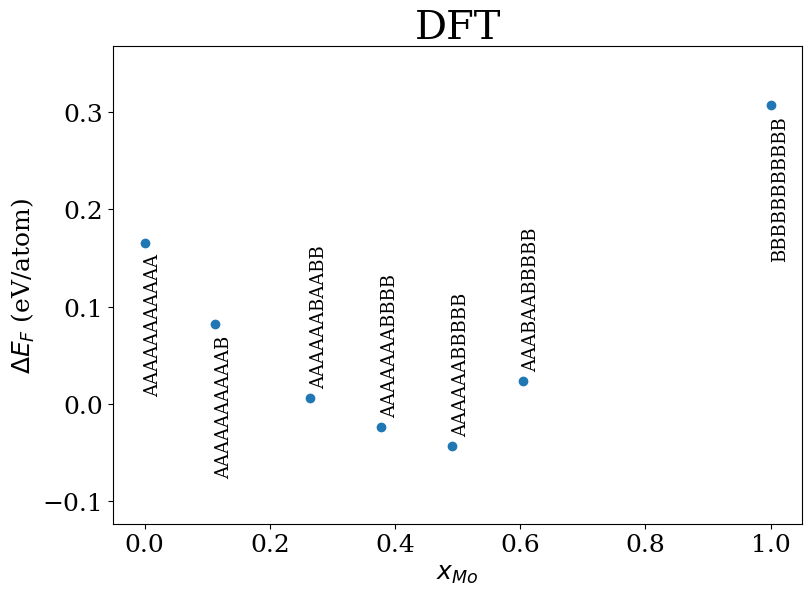

In [74]:
fname = 'EF'
fig, ax, saved_path = plot_tagged_chull(chull_w_compo, fname, figw, figh)
saved_path

In [75]:
chull_w_compo.query('index.str.contains("AAAAAABAABB")')

,Configuration,Fe,Mo,EF_nmhcp__0.7dprojections_0.5os,EF_nmhcp__ACE,EF_nmhcp__SOAP_specific_small,EF
Fe_pv39Mo_sv14.R-AAAAAABAABB.NM,R-AAAAAABAABB,0.735849,0.264151,[0.02756],[0.03121],0.008024,0.006513


'../Fe-Mo/graphs/Fe-Mo_tagged_chull_EF_nmhcp__ACE.pdf'

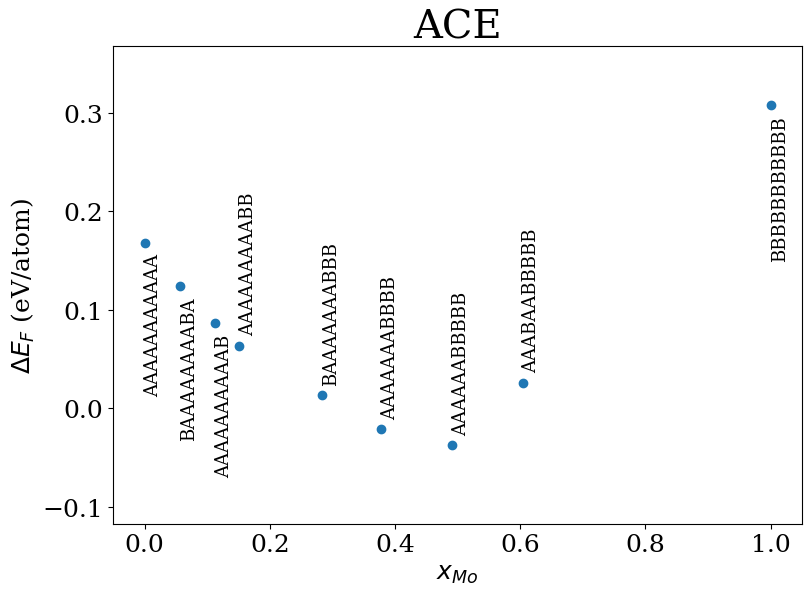

In [76]:
fname = 'EF_nmhcp__ACE'
fig, ax, saved_path = plot_tagged_chull(chull_w_compo, fname, figw, figh)
saved_path

In [77]:
saved_path

'../Fe-Mo/graphs/Fe-Mo_tagged_chull_EF_nmhcp__ACE.pdf'

'../Fe-Mo/graphs/Fe-Mo_tagged_chull_EF_nmhcp__0_7dprojections_0_5os.pdf'

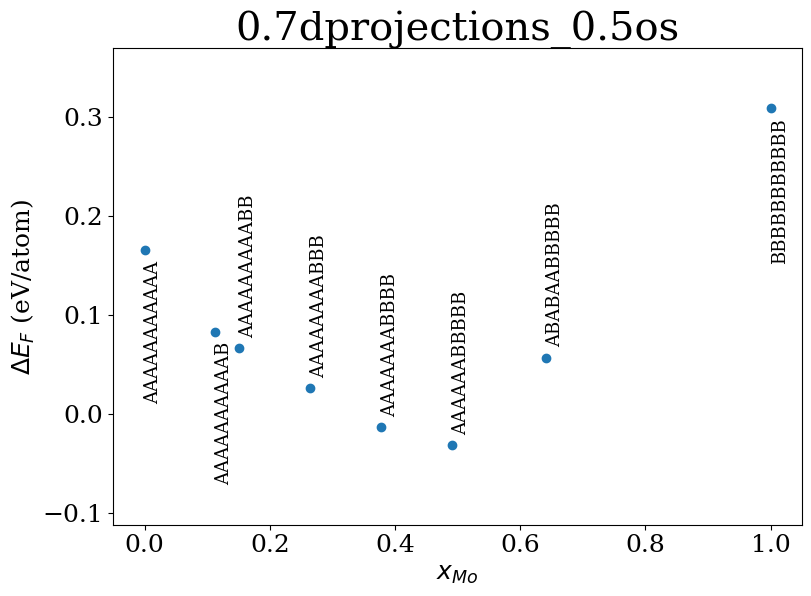

In [78]:
fname = 'EF_nmhcp__0.7dprojections_0.5os'
fig, ax, saved_path = plot_tagged_chull(chull_w_compo, fname, figw, figh)
saved_path

'../Fe-Mo/graphs/Fe-Mo_tagged_chull_EF_nmhcp__SOAP_specific_small.pdf'

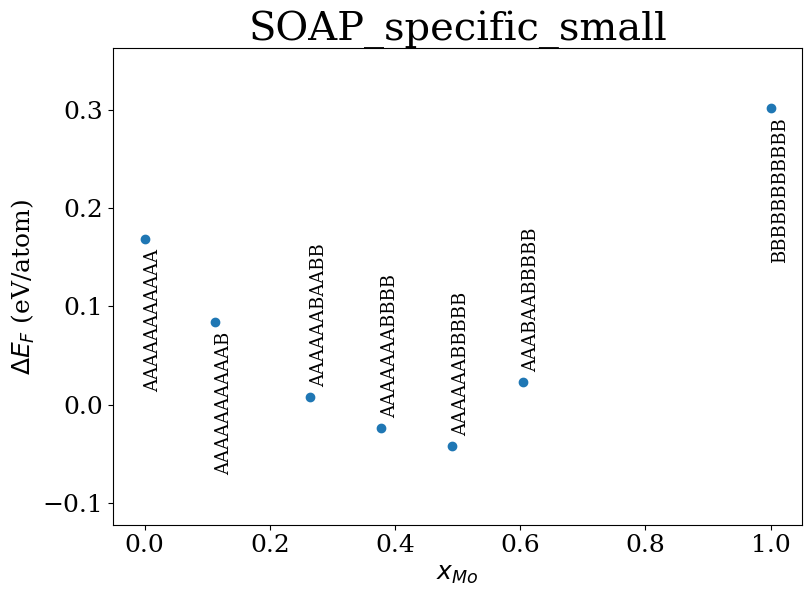

In [79]:
fname = 'EF_nmhcp__SOAP_specific_small'
fig, ax, saved_path = plot_tagged_chull(chull_w_compo, fname, figw, figh)
saved_path

# Calculate new DFT convex hull for R